Sample Data:
    Soil_Nitrogen    Rainfall  Temperature  Water_Usage  Label
0      74.967142  632.408397    17.923146   420.039428      1
1      68.617357  561.491772    22.896773   427.715857      1
2      76.476885  532.307800    23.286427   345.598022      0
3      85.230299  661.167629    20.988614   418.580296      1
4      67.658466  703.099952    24.193571   423.445798      1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6750 - loss: 0.6876
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6750 - loss: 0.6777 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6750 - loss: 0.6667 
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6750 - loss: 0.6574 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6750 - loss: 0.6483 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6750 - loss: 0.6405 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6750 - loss: 0.6321 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6750 - loss: 0.6235  
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6750 - loss: 0.6158 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6750 - loss: 0.6080 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6750 - loss: 0.5998 
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6750 - loss: 0.5936 

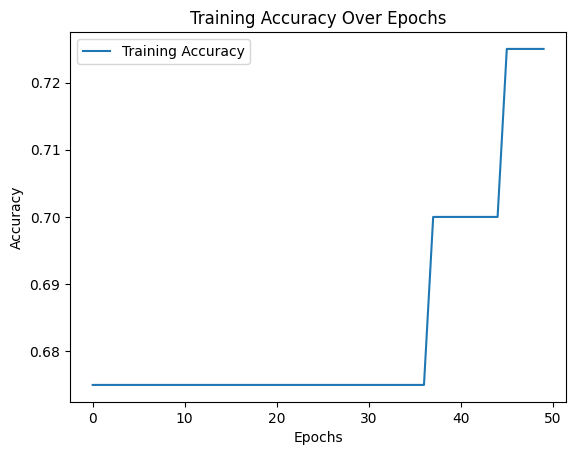

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. GENEARATE DATASET(50 samples)
np.random.seed(42)
n_samples=50
data=pd.DataFrame ({
    "Soil_Nitrogen": np.random.normal(70,10,n_samples),
    "Rainfall": np.random.normal(600,100,n_samples),
    "Temperature": np.random.normal(25,5,n_samples),
    "Water_Usage": np.random.normal(400,80,n_samples),
    })

# CREATE CLASSIFICATION LABEL(Healthy=1,Unhealthy=0)
data["Label"]=(
    (data["Soil_Nitrogen"]>65) &
    (data["Rainfall"]>550) &
    (data["Water_Usage"]>350)
).astype(int)
print("Sample Data:\n",data.head())

# 2.  SPLIT FEATURES & LABELS
X=data.drop("Label",axis=1)
y=data["Label"]

# 3. TRAIN-TEST SPLIT
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# 4. FEATURE SCALING
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

# 5. BUILD 'ANN' MODEL
model=Sequential()


#Input+ Hidden Layers
model.add(Dense(8,activation='relu',input_dim=X_train.shape[1]))
model.add(Dense(6,activation='relu'))

# Output Layer (Binary Classification)
model.add(Dense(1,activation='sigmoid'))

# 6. COMPILE MODEL
model.compile(
    optimizer='Adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 7. TRAIN MODEL
history=model.fit(
    X_train,y_train,
    epochs=50,
    batch_size=5,
    verbose=1
    )
# 8. PREDICTIONS
y_pred=model.predict(X_test)
y_pred=(y_pred>0.5).astype(int)

# 9.EVALUATION METRICS
print("\n --- MODEL EVALUATION ---")
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

print("\n CONFUSION MATRIX :\n",confusion_matrix(y_test,y_pred))
print("\n CLASSIFICATION REPORT :\n",classification_report(y_test,y_pred))

# 10. PLOT TRAINING PERFROMANCE
plt.figure()
plt.plot(history.history['accuracy'],label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Over Epochs")
plt.legend()
plt.show()